
========== Benchmark Attribution ==========
Portfolio Return : 2.52%
Benchmark Return : 2.15%
Active Return    : 0.37%

========== Key Rate Duration Attribution ==========
  Tenor  Portfolio_KRD  Yield_Shock  Attribution
0    2Y            0.5       0.0005     -0.00025
1    5Y            2.0       0.0010     -0.00200
2   10Y            3.5      -0.0020      0.00700
3   30Y            1.2      -0.0015      0.00180

========== Sector Allocation Attribution ==========
            Weight  Return  Benchmark Weight  Benchmark Return  \
Sector                                                           
Corporate     0.45  0.0300               0.3             0.025   
Government    0.55  0.0213               0.7             0.020   

            Allocation Effect  
Sector                         
Corporate              0.0013  
Government             0.0000  

========== Curve Positioning Attribution ==========
  Maturity  Portfolio_Duration  Yield_Move  Curve_Positioning_Return
0       2Y    

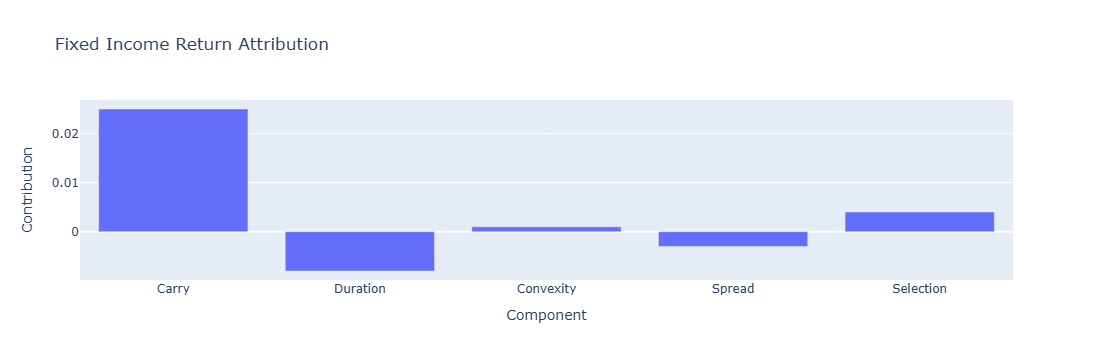

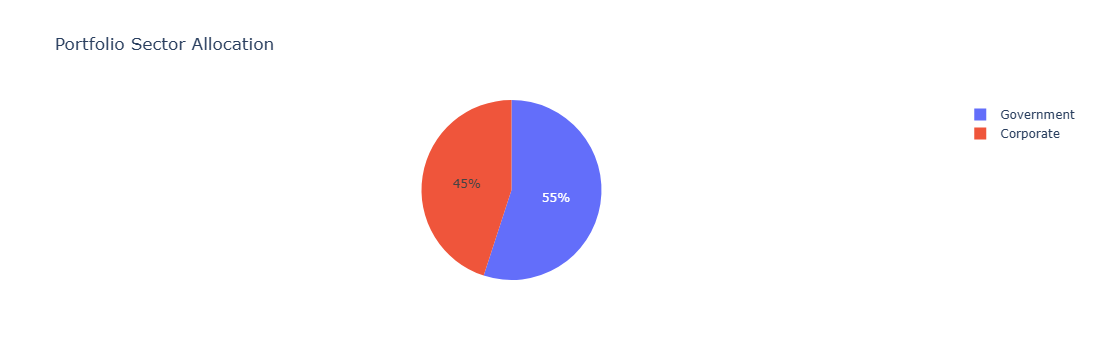

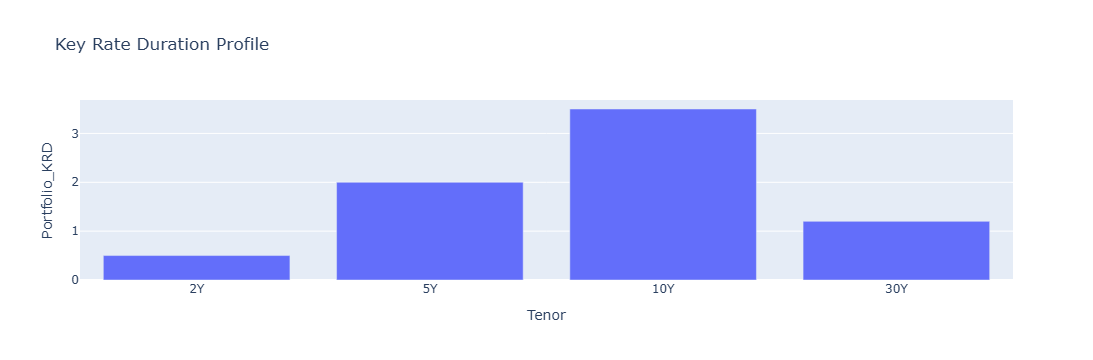

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px


####################################################
# Example Portfolio and Benchmark
####################################################

portfolio = pd.DataFrame({

    "Bond":[
        "US Treasury 5Y",
        "German Bund 10Y",
        "Corporate Bond A",
        "Corporate Bond B",
        "French OAT 8Y"
    ],

    "Sector":[
        "Government",
        "Government",
        "Corporate",
        "Corporate",
        "Government"
    ],

    "Weight":[
        0.20,
        0.25,
        0.25,
        0.20,
        0.10
    ],

    "Duration":[
        4.8,
        8.9,
        5.7,
        7.2,
        6.5
    ],

    "Return":[
        0.025,
        0.018,
        0.032,
        0.028,
        0.021
    ]
})


benchmark = pd.DataFrame({
    "Sector":["Government", "Corporate"],
    "Weight":[0.70, 0.30],
    "Duration":[7.0, 6.0],
    "Return":[0.020, 0.025] })


####################################################
# 1. Benchmark Attribution
####################################################

portfolio_return = np.sum(portfolio.Weight *portfolio.Return)
benchmark_return = np.sum(benchmark.Weight *benchmark.Return)
active_return = (portfolio_return -benchmark_return)


print("\n========== Benchmark Attribution ==========")
print(f"Portfolio Return : {portfolio_return:.2%}")
print(f"Benchmark Return : {benchmark_return:.2%}")
print(f"Active Return    : {active_return:.2%}")


####################################################
# 2. Key Rate Duration Attribution
####################################################

key_rates = pd.DataFrame({

    "Tenor":[
        "2Y",
        "5Y",
        "10Y",
        "30Y"
    ],

    "Portfolio_KRD":[
        0.5,
        2.0,
        3.5,
        1.2
    ],

    "Yield_Shock":[
        0.0005,
        0.0010,
        -0.0020,
        -0.0015
    ]

})


key_rates["Attribution"] = (
    -key_rates.Portfolio_KRD *
    key_rates.Yield_Shock
)


print("\n========== Key Rate Duration Attribution ==========")
print(key_rates.round(5))



####################################################
# 3. Sector Allocation Attribution
####################################################

sector = portfolio.groupby("Sector").agg({"Weight":"sum","Return":"mean"})
benchmark_sector = benchmark.set_index("Sector")
sector["Benchmark Weight"] = (benchmark_sector.Weight)
sector["Benchmark Return"] = (benchmark_sector.Return)
sector["Allocation Effect"] = (
    (sector.Weight -sector["Benchmark Weight"])*
    (sector["Return"] - benchmark_return))


print("\n========== Sector Allocation Attribution ==========")
print(sector.round(4))



####################################################
# 4. Yield Curve Positioning Attribution
####################################################

curve = pd.DataFrame({

    "Maturity":[
        "2Y",
        "5Y",
        "10Y",
        "30Y"
    ],

    "Portfolio_Duration":[
        0.8,
        2.2,
        3.5,
        1.5
    ],

    "Yield_Move":[
        0.001,
        -0.002,
        -0.003,
        -0.001
    ]

})


curve["Curve_Positioning_Return"] = (-curve.Portfolio_Duration *curve.Yield_Move)


print("\n========== Curve Positioning Attribution ==========")
print(curve.round(5))



####################################################
# 5. Brinson Fixed Income Attribution
####################################################

brinson = pd.DataFrame({

    "Sector":[
        "Government",
        "Corporate"
    ],

    "Portfolio Weight":[
        0.45,
        0.55
    ],

    "Benchmark Weight":[
        0.70,
        0.30
    ],

    "Portfolio Return":[
        0.021,
        0.031
    ],

    "Benchmark Return":[
        0.020,
        0.025
    ]

})


# Allocation effect
brinson["Allocation Effect"] = (
    (brinson["Portfolio Weight"] - brinson["Benchmark Weight"])
    *
    (brinson["Benchmark Return"] - benchmark_return))



# Selection effect
brinson["Selection Effect"] = (
    brinson["Benchmark Weight"]
    *
    (brinson["Portfolio Return"] - brinson["Benchmark Return"]))


# Interaction effect
brinson["Interaction Effect"] = (
    (brinson["Portfolio Weight"] - brinson["Benchmark Weight"])
    *
    (brinson["Portfolio Return"] - brinson["Benchmark Return"]))


print("\n========== Brinson Attribution ==========")
print(brinson.round(4))



####################################################
# 6. Interactive Plotly Dashboard
####################################################


# Attribution waterfall data

dashboard = pd.DataFrame({

    "Component":[

        "Carry",

        "Duration",

        "Convexity",

        "Spread",

        "Selection"

    ],


    "Contribution":[

        0.025,

        -0.008,

        0.001,

        -0.003,

        0.004

    ]

})



fig1 = px.bar(

    dashboard,

    x="Component",

    y="Contribution",

    title="Fixed Income Return Attribution"

)


fig1.show()



# Sector allocation chart


fig2 = px.pie(

    portfolio,

    values="Weight",

    names="Sector",

    title="Portfolio Sector Allocation"

)


fig2.show()



# Key rate duration chart


fig3 = px.bar(

    key_rates,

    x="Tenor",

    y="Portfolio_KRD",

    title="Key Rate Duration Profile"

)


fig3.show()